# Transformer Model for AI Text Detection

This notebook implements a custom Transformer model for detecting AI-generated text:
1. Data loading and preprocessing
2. Text tokenization and sequence creation
3. Transformer encoder architecture
4. Model training and evaluation
5. Model saving


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re
import string
import os
import pickle
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


2025-04-01 23:35:49.617537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 23:35:49.665539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743546949.723792   36407 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743546949.744854   36407 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-01 23:35:49.810548: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Define Preprocessing Functions

In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

def extract_features(texts):
    print("Extracting features...")
    features = []
    stop_words = set(stopwords.words("english"))

    for text in texts:
        if not isinstance(text, str) or not text.strip():
            features.append([0] * 8)
            continue
            
        words = word_tokenize(text)
        
        if not words:
            features.append([0] * 8)
            continue
            
        num_words = len(words)
        num_chars = len(text)
        avg_word_length = np.mean([len(w) for w in words]) if words else 0
        num_stopwords = sum(1 for word in words if word.lower() in stop_words)
        stopword_ratio = num_stopwords / num_words if num_words else 0
        
        num_punctuation = sum(1 for char in text if char in string.punctuation)
        punctuation_ratio = num_punctuation / num_chars if num_chars else 0
        
        lexical_diversity = len(set(words)) / num_words if num_words else 0
        
        feature_vector = [
            num_words,
            num_chars,
            avg_word_length,
            num_stopwords,
            stopword_ratio,
            num_punctuation,
            punctuation_ratio,
            lexical_diversity
        ]
        
        features.append(feature_vector)
        
    return np.array(features)

## Data Preparation

In [4]:
print("Loading dataset...")
df = pd.read_csv("../../datasets/custom_dataset.csv", sep="\t")
print(f"Dataset shape: {df.shape}")
df.head()

df['cleaned_text'] = df['Text'].apply(clean_text)

labels = df['Label'].apply(lambda x: 0 if x == 'Human' else 1).values

print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['cleaned_text'].values, labels, test_size=0.3, random_state=2025, stratify=labels
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=2025, stratify=temp_labels
)

print(f"Training set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Loading dataset...
Dataset shape: (5437, 2)
Label distribution: {1: 3461, 0: 1976}
Training set: 3805 samples
Validation set: 816 samples
Test set: 816 samples


In [5]:
max_words = 10000
max_seq_length = 256

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_seq_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_length, padding='post', truncating='post')

print(f"Training sequences shape: {train_padded.shape}")
print(f"Validation sequences shape: {val_padded.shape}")
print(f"Test sequences shape: {test_padded.shape}")


Vocabulary size: 10000
Training sequences shape: (3805, 256)
Validation sequences shape: (816, 256)
Test sequences shape: (816, 256)


## Model Architecture

In [6]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.Dropout(dropout)(x)
    
    return x + res

def build_transformer_model(
    max_seq_length,
    vocab_size,
    embed_dim=128,
    num_heads=2,
    ff_dim=128,
    num_transformer_blocks=2,
    mlp_units=[64],
    dropout=0.1,
    mlp_dropout=0.1,
):
    inputs = layers.Input(shape=(max_seq_length,))
    
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        embeddings_initializer=initializers.GlorotUniform(seed=2025)
    )(inputs)
    
    positions = tf.range(start=0, limit=max_seq_length, delta=1)
    position_embeddings = layers.Embedding(
        input_dim=max_seq_length,
        output_dim=embed_dim,
        embeddings_initializer=initializers.GlorotUniform(seed=2025)
    )(positions)
    x = x + position_embeddings
    
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, embed_dim // num_heads, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

transformer_model = build_transformer_model(
    max_seq_length=max_seq_length,
    vocab_size=vocab_size,
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_transformer_blocks=4,
    mlp_units=[128, 64],
    dropout=0.1,
    mlp_dropout=0.1,
)

transformer_model.summary()


W0000 00:00:1743546962.296559   36407 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 128)  │          0 │ dropout_1[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 256)  │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 128)  │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256, 128)  │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 128)  │          0 │ dropout_3[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 128)  │          0 │ dropout_5[0][0],  │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,834,753 (7.00 MB)

 Trainable params: 1,834,753 (7.00 MB)

 Non-trainable params: 0 (0.00 B)

## Hyperparameter Tuning

In [7]:
from keras_tuner import Hyperband

def build_tunable_transformer(hp):
    embed_dim = hp.Int("embed_dim", min_value=16, max_value=128, step=16)
    num_heads = hp.Int("num_heads", min_value=1, max_value=6, step=1)
    ff_dim = hp.Int("ff_dim", min_value=32, max_value=256, step=32)
    num_transformer_blocks = hp.Int("num_transformer_blocks", min_value=1, max_value=4, step=1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    learning_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-3, sampling="log")
    
    model = build_transformer_model(
        max_seq_length=max_seq_length,
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_transformer_blocks=num_transformer_blocks,
        mlp_units=[embed_dim // 2, embed_dim // 4],
        dropout=dropout_rate,
        mlp_dropout=dropout_rate,
    )
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

tuner = Hyperband(
    build_tunable_transformer,
    objective="val_accuracy",
    max_epochs=10,
    factor=3,
    directory="../../tuner_results",
    project_name="transformer_tuning"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

print("Starting hyperparameter tuning...")
tuner.search(
    train_padded, train_labels,
    validation_data=(val_padded, val_labels),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

best_model = tuner.hypermodel.build(best_hps)


Trial 30 Complete [00h 01m 32s]
val_accuracy: 0.9926470518112183

Best val_accuracy So Far: 0.9950980544090271
Total elapsed time: 00h 58m 02s
Best hyperparameters: {'embed_dim': 128, 'num_heads': 6, 'ff_dim': 64, 'num_transformer_blocks': 1, 'dropout_rate': 0.2, 'learning_rate': 0.00010921966346375464, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0015'}


## Model Training

Training transformer model...
Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5972 - auc_3: 0.5465 - loss: 0.6634 - precision_3: 0.6424 - recall_3: 0.8324

119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 166ms/step - accuracy: 0.5978 - auc_3: 0.5475 - loss: 0.6631 - precision_3: 0.6427 - recall_3: 0.8330 - val_accuracy: 0.8958 - val_auc_3: 0.9871 - val_loss: 0.3474 - val_precision_3: 0.8643 - val_recall_3: 0.9923 - learning_rate: 1.0922e-04
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9330 - auc_3: 0.9808 - loss: 0.2354 - precision_3: 0.9369 - recall_3: 0.9600

119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 189ms/step - accuracy: 0.9332 - auc_3: 0.9808 - loss: 0.2347 - precision_3: 0.9371 - recall_3: 0.9601 - val_accuracy: 0.9853 - val_auc_3: 0.9991 - val_loss: 0.0433 - val_precision_3: 0.9811 - val_recall_3: 0.9962 - learning_rate: 1.0922e-04
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9920 - auc_3: 0.9995 - loss: 0.0343 - precision_3: 0.9928 - recall_3: 0.9946

119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 198ms/step - accuracy: 0.9920 - auc_3: 0.9995 - loss: 0.0342 - precision_3: 0.9928 - recall_3: 0.9946 - val_accuracy: 0.9902 - val_auc_3: 0.9989 - val_loss: 0.0232 - val_precision_3: 0.9981 - val_recall_3: 0.9865 - learning_rate: 1.0922e-04
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9994 - auc_3: 1.0000 - loss: 0.0084 - precision_3: 1.0000 - recall_3: 0.9991

119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 209ms/step - accuracy: 0.9994 - auc_3: 1.0000 - loss: 0.0084 - precision_3: 1.0000 - recall_3: 0.9991 - val_accuracy: 0.9939 - val_auc_3: 0.9989 - val_loss: 0.0221 - val_precision_3: 0.9961 - val_recall_3: 0.9942 - learning_rate: 1.0922e-04
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9995 - auc_3: 1.0000 - loss: 0.0036 - precision_3: 0.9997 - recall_3: 0.9995

119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 190ms/step - accuracy: 0.9995 - auc_3: 1.0000 - loss: 0.0036 - precision_3: 0.9997 - recall_3: 0.9995 - val_accuracy: 0.9926 - val_auc_3: 0.9989 - val_loss: 0.0209 - val_precision_3: 0.9961 - val_recall_3: 0.9923 - learning_rate: 1.0922e-04
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.9998 - auc_3: 1.0000 - loss: 0.0019 - precision_3: 0.9997 - recall_3: 1.0000 - val_accuracy: 0.9926 - val_auc_3: 0.9990 - val_loss: 0.0228 - val_precision_3: 0.9961 - val_recall_3: 0.9923 - learning_rate: 1.0922e-04
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 1.0000 - auc_3: 1.0000 - loss: 0.0010 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 0.9926 - val_auc_3: 0.9990 - val_loss: 0.0238 - val_precision_3: 0.9961 - val_recall_3: 0.9923 - learning_rate: 1.0922e-04
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 207ms/step - accuracy: 1.0000 - auc_3: 1.0000 - loss: 8.0489e-04 - precision_3: 1.0000 - recall_3: 1.0000 - val_

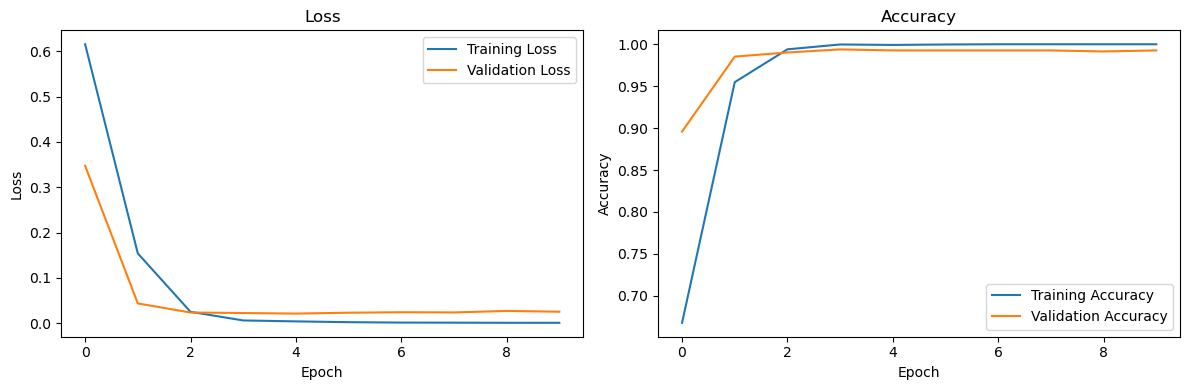

In [8]:
os.makedirs('../../trained_models/tensorflow', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('../../trained_models/tensorflow/transformer_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

print("Training transformer model...")
history = best_model.fit(
    train_padded, train_labels,
    validation_data=(val_padded, val_labels),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Model Evaluation

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9900 - auc_3: 0.9976 - loss: 0.0346 - precision_3: 0.9844 - recall_3: 1.0000
Test accuracy: 0.9914
Test AUC: 0.9982
Test precision: 0.9867
Test recall: 1.0000
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


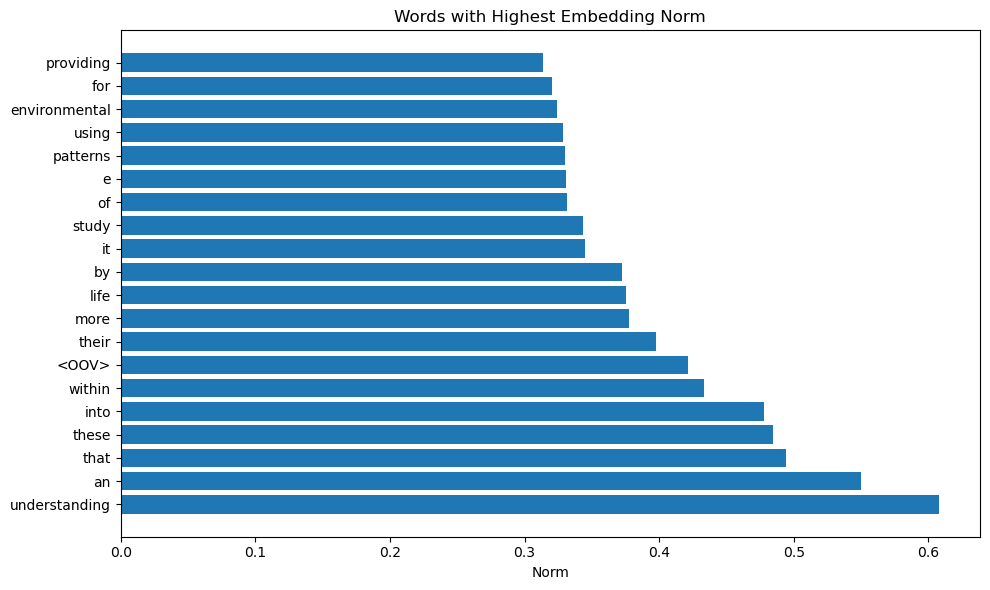

In [20]:
transformer_model = best_model

test_loss, test_acc, test_auc, test_precision, test_recall = transformer_model.evaluate(test_padded, test_labels)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")

y_pred_prob = transformer_model.predict(test_padded)
y_pred = (y_pred_prob > 0.5).astype(int)

try:
    embedding_layer = transformer_model.layers[1]
    embedding_weights = embedding_layer.get_weights()[0]
    
    word_norms = np.linalg.norm(embedding_weights, axis=1)
    top_indices = np.argsort(word_norms)[-20:]
    
    index_word = {v: k for k, v in tokenizer.word_index.items()}
    top_words = [index_word.get(i+1, '') for i in top_indices if i+1 in index_word]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_words)), word_norms[top_indices][::-1])
    plt.yticks(range(len(top_words)), top_words[::-1])
    plt.title('Words with Highest Embedding Norm')
    plt.xlabel('Norm')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not visualize embeddings: {str(e)}")


## Model Deployment

In [22]:
transformer_model.save('../../trained_models/tensorflow/transformer_model.h5')
print("Model saved to '../../trained_models/tensorflow/transformer_model.h5'")

with open('../../trained_models/tensorflow/transformer_tokenizer.pkl', 'wb') as f:
    pickle.dump({
        'tokenizer': tokenizer,
        'max_seq_length': max_seq_length,
        'clean_text': clean_text,
        'extract_features': extract_features
    }, f)
print("Tokenizer saved to '../../trained_models/tensorflow/transformer_tokenizer.pkl'")

def predict_text(text, model, preprocessor):
    cleaned_text = preprocessor['clean_text'](text)
    
    sequence = preprocessor['tokenizer'].texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
    
    prediction = model.predict(padded)[0][0]
    
    return {
        'probability': float(prediction),
        'prediction': 'AI' if prediction > 0.5 else 'Human'
    }

loaded_model = best_model
with open('../../trained_models/tensorflow/transformer_tokenizer.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

sample_text = "This is a sample text to test the model."
result = predict_text(sample_text, loaded_model, loaded_preprocessor)
print(f"Sample text: '{sample_text}'")
print(f"Prediction: {result['prediction']} (Probability: {result['probability']:.4f})")

Model saved to '../../trained_models/tensorflow/transformer_model.h5'
Tokenizer saved to '../../trained_models/tensorflow/transformer_tokenizer.pkl'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Sample text: 'This is a sample text to test the model.'
Prediction: Human (Probability: 0.0001)


## Calculate Accuracy on Test Dataset

Loading teacher inputs...
Loaded 130 teacher inputs
     ID                                               Text
0  D1-1  The cell cycle, or cell-division cycle, is the...
1  D1-2  The cell cycle is the process by which a cell ...
2  D1-3  Photons, in many atomic models in physics, are...
3  D1-4  A photon is a fundamental particle of light an...
4  D1-5  According to the theory of plate tectonics, Ea...

Loading teacher outputs...
Loaded 130 teacher outputs
     ID  Label
0  D1-1  Human
1  D1-2     AI
2  D1-3  Human
3  D1-4     AI
4  D1-5  Human

Evaluating on 130 samples...

Prediction Results:
        ID True_Label Predicted_Label  Probability  Correct
0     D1-1      Human           Human     0.048886     True
1     D1-2         AI              AI     0.997788     True
2     D1-3      Human           Human     0.000031     True
3     D1-4         AI              AI     0.541023     True
4     D1-5      Human           Human     0.000211     True
..     ...        ...             ... 

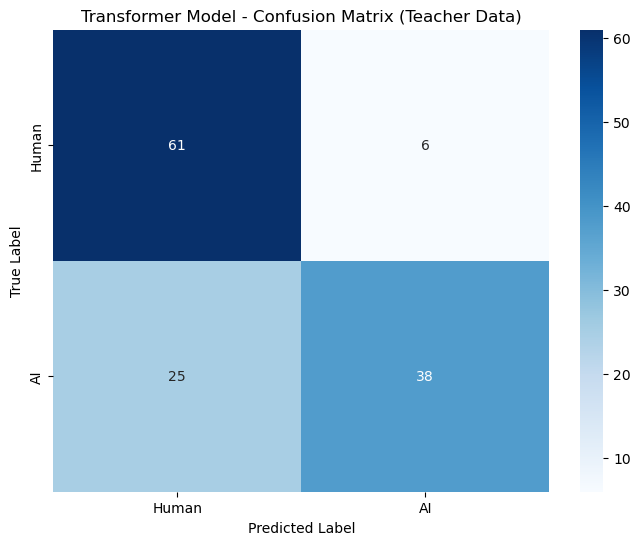

In [24]:
def predict_text(text, model, preprocessor):
    cleaned_text = preprocessor['clean_text'](text)
    
    sequence = preprocessor['tokenizer'].texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
    
    prediction = model.predict(padded, verbose=0)[0][0]
    
    return {
        'probability': float(prediction),
        'prediction': 'AI' if prediction > 0.5 else 'Human'
    }

print("Loading teacher inputs...")
teacher_inputs = pd.read_csv('../../datasets/clean/teacher_inputs.csv', sep='\t')
print(f"Loaded {len(teacher_inputs)} teacher inputs")
print(teacher_inputs.head())

print("\nLoading teacher outputs...")
teacher_outputs = pd.read_csv('../../datasets/clean/teacher_outputs.csv', sep='\t')
print(f"Loaded {len(teacher_outputs)} teacher outputs")
print(teacher_outputs.head())

if not all(teacher_inputs['ID'] == teacher_outputs['ID']):
    print("Warning: IDs in teacher_inputs and teacher_outputs don't match!")
    evaluation_data = pd.merge(teacher_inputs, teacher_outputs, on='ID')
else:
    evaluation_data = teacher_inputs.copy()
    evaluation_data['Label'] = teacher_outputs['Label']

print(f"\nEvaluating on {len(evaluation_data)} samples...")

try:
    preprocessor = {
        'tokenizer': tokenizer,
        'max_seq_length': max_seq_length,
        'clean_text': clean_text
    }
except NameError:
    print("Loading preprocessor from disk...")
    with open('../../trained_models/tensorflow/transformer_tokenizer.pkl', 'rb') as f:
        preprocessor = pickle.load(f)

results = []
for idx, row in evaluation_data.iterrows():
    text = row['Text']
    true_label = row['Label']
    
    result = predict_text(text, best_model, preprocessor)
    
    results.append({
        'ID': row['ID'],
        'Text': text[:100] + '...' if len(text) > 100 else text, 
        'True_Label': true_label,
        'Predicted_Label': result['prediction'],
        'Probability': result['probability'],
        'Correct': result['prediction'] == true_label
    })

results_df = pd.DataFrame(results)
print("\nPrediction Results:")
print(results_df[['ID', 'True_Label', 'Predicted_Label', 'Probability', 'Correct']])

accuracy = results_df['Correct'].mean()
print(f"\nAccuracy: {accuracy:.4f} ({results_df['Correct'].sum()} / {len(results_df)})")

true_labels = [1 if label == 'AI' else 0 for label in results_df['True_Label']]
pred_labels = [1 if label == 'AI' else 0 for label in results_df['Predicted_Label']]

plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)
plt.title('Transformer Model - Confusion Matrix (Teacher Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()